In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
#Establece la carpeta de trabajo al directorio raíz del proyecto
import os
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from src.visualization import *
from src.statistics import *
from src.market import Mercado

from dataclasses import replace
from tqdm.notebook import tqdm  # Barra de progreso especial para Jupyter

In [22]:
from experiments.main_experiment import config_particular

config = config_particular()  # Carga la configuración del experimento

In [23]:
# 1. Cargar los datos macro
# Ajusta la ruta si tu notebook no está en la raíz del proyecto
ruta_macro = "./data/raw/convergencia_hayek_01_macro.parquet"
df_macro = pd.read_parquet(ruta_macro)

# 2. Inspección básica de la estructura
print("--- ESTRUCTURA MACRO ---")
print(f"Dimensiones (Periodos, Cadenas): {df_macro.shape}")
display(df_macro.head()) # Muestra los primeros 5 periodos

--- ESTRUCTURA MACRO ---
Dimensiones (Periodos, Cadenas): (10000, 3)


,Cadena_1,Cadena_2,Cadena_3
0,0.491084,1.492422,4.498184
1,0.491254,1.508769,4.491740
2,0.487839,1.507960,4.487658
3,0.489436,1.511917,4.450128
4,0.488345,1.521104,4.418091


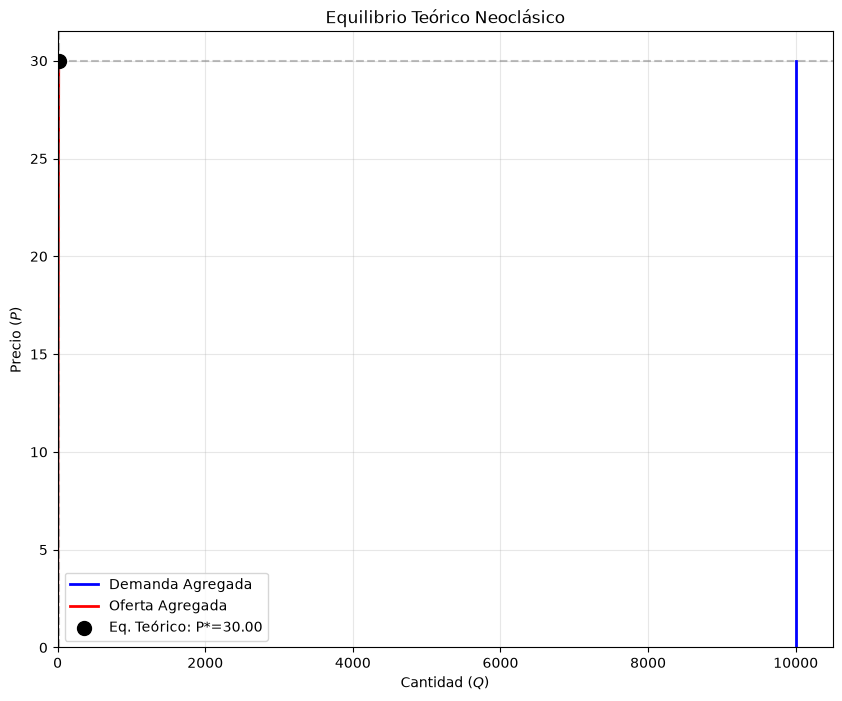

Precio de equilibrio (P): 30.0
Cantidad de equilibrio (Q): 15.0


In [24]:
ax = graficar_cruz_marshalliana(config)
plt.show()

P, Q = calcular_equilibrio_marshalliano(config)
print(f"Precio de equilibrio (P): {P}")
print(f"Cantidad de equilibrio (Q): {Q}")

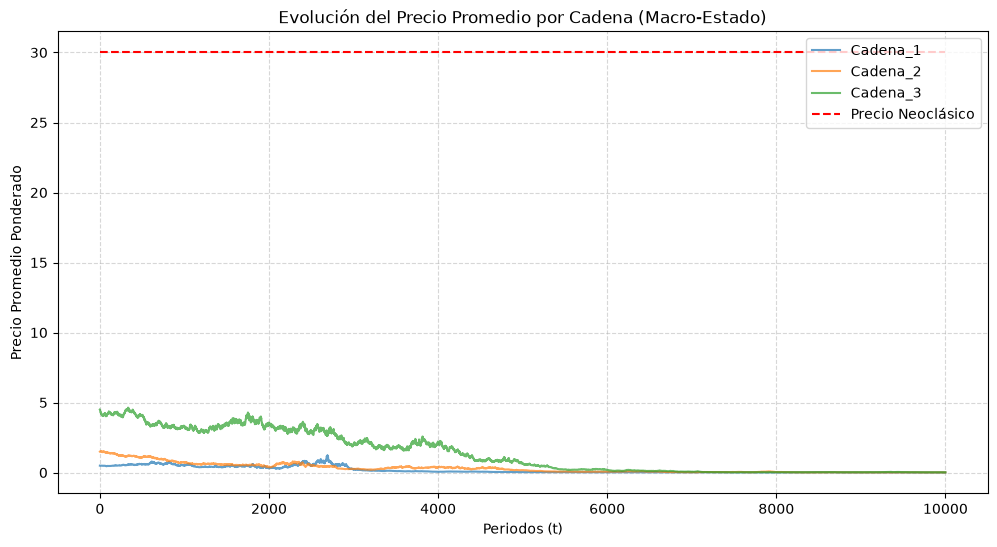

In [25]:
# 3. Visualización de la convergencia
# Graficamos todas las columnas (cadenas) a lo largo del índice (periodos)
ax = df_macro.plot(
    figsize=(12, 6), 
    alpha=0.7, 
    linewidth=1.5,
    title="Evolución del Precio Promedio por Cadena (Macro-Estado)"
)

ax.hlines(y = P, xmin = df_macro.index.min(), xmax = df_macro.index.max(), colors='red', linestyles='--', label='Precio Neoclásico')
ax.set_xlabel("Periodos (t)")
ax.set_ylabel("Precio Promedio Ponderado")
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend()
plt.show()

Simulando niveles de información:   0%|          | 0/20 [00:00<?, ?it/s]

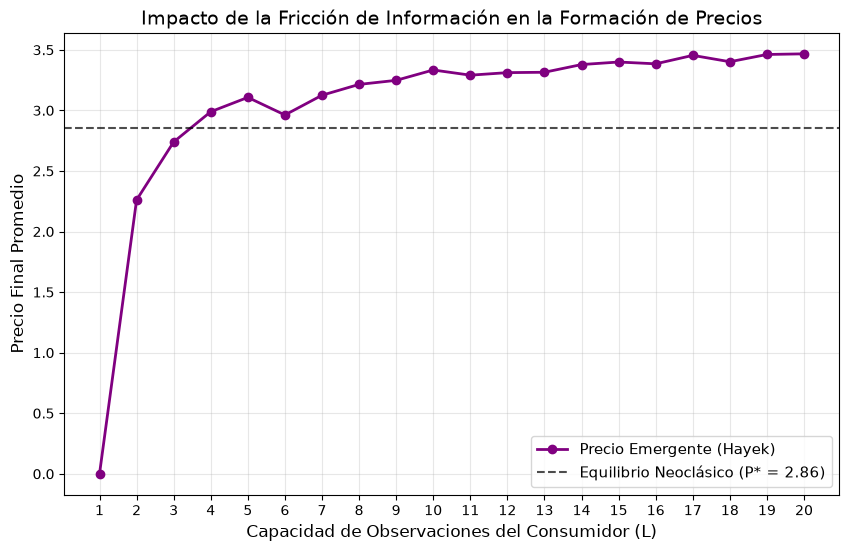

In [16]:
# 2. Definimos nuestro espacio de experimentación
valores_busqueda = list(range(1, 21))
precios_finales_promedio = []

# (Ajusta estos periodos al número que estés usando en tu modelo)
T_MAX = 3000  

# 3. Bucle de experimentación
for d_search in tqdm(valores_busqueda, desc="Simulando niveles de información"):
    
    # Clonamos la configuración inyectando el nuevo nivel de búsqueda
    nuevas_instituciones = replace(config.instituciones, deepest_search=4*d_search//5, L = d_search)
    config_actual = replace(config, instituciones=nuevas_instituciones)
    
    # Instanciamos y corremos el mercado
    mercado = Mercado(config_actual)
    
    # IMPORTANTE: Reemplaza esta línea por tu método real para correr los periodos
    # Por ejemplo: mercado.simular(T_MAX) 
    for t in range(T_MAX):
        mercado.ejecutar_periodo(t) 
        if t > 500:
            r_hat = calcular_gelman_rubin(mercado.historial_precios_macro, R_window = config.instituciones.R)
            if r_hat < config.instituciones.G:
                break  # Convergencia alcanzada, salimos del bucle de periodos
        
    # --- EXTRACCIÓN DE DATOS ---
    # 1. Precio final: promedio de las J cadenas en la última columna (-1)
    precios_ultimo_periodo = mercado.historial_precios_macro[:, -1]
    precio_final = np.mean(precios_ultimo_periodo)
    precios_finales_promedio.append(precio_final)

# 4. Visualización del impacto institucional
fig, ax = plt.subplots(figsize=(10, 6))

# Trazamos los resultados emergentes
ax.plot(valores_busqueda, precios_finales_promedio, 
        marker='o', linestyle='-', color='purple', linewidth=2, 
        label='Precio Emergente (Hayek)')

# Trazamos la línea de base teórica
ax.axhline(P, color='black', linestyle='--', alpha=0.7, 
           label=f'Equilibrio Neoclásico (P* = {P:.2f})')

# Formato académico
ax.set_title("Impacto de la Fricción de Información en la Formación de Precios", fontsize=14)
ax.set_xlabel("Capacidad de Observaciones del Consumidor (L)", fontsize=12)
ax.set_ylabel("Precio Final Promedio", fontsize=12)
ax.set_xticks(valores_busqueda)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.show()